# SVD + Clustering

In [158]:
!pip install -q numpy pandas kagglehub torch matplotlib scipy

In [159]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import kagglehub

from scipy.sparse.linalg import svds

## Data Load

### Data_imdb (Don't use this)

In [160]:
# Download latest version
path = kagglehub.dataset_download("sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k")

print("Path to dataset files:", path)


df = pd.read_csv(path + "/prepd_data.csv")

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k/versions/1


### Data_imdb_50K (Use this)

In [ ]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)\

# df = pd.read_csv(path + "/IMDB Dataset.csv")

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


### Clean Data and Label

In [162]:
text_col = "review"
label_col = "sentiment"

# remove missing value
df = df[[text_col, label_col]].dropna().copy()

# label encoding
# positive -> 1, negative -> 0
df[label_col] = df[label_col].map({"positive": 1, "negative": 0})

## Split test train data

In [163]:
def train_test_split(X, Y, test_size, random_seed):
    x = np.array(X)
    y = np.array(Y)

    n_samples = len(x)
    if n_samples != len(y):
        print("X and Y are not same")
        return
    np.random.seed(random_seed)

    classes = np.unique(y)

    train_indices = []
    test_indices = []

    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)

        test_count = int(len(cls_indices) * test_size)

        test_cls_indices = cls_indices[:test_count]
        train_cls_indices = cls_indices[test_count:]

        test_indices.extend(test_cls_indices)
        train_indices.extend(train_cls_indices)

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


In [ ]:
X = df[text_col].values
Y = df[label_col].values


X_train, X_test, y_train, y_test = train_test_split(
    X=X,
    Y=Y,
    test_size=0.2,
    random_seed=42,
)

#max_train = 10000

#X_train = X_train[:max_train]
#y_train = y_train[:max_train]

train_df = (X_train, y_train)
test_df = (X_test, y_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

labels, counts = np.unique(y_train, return_counts=True)

print("Train label distribution:")
for l, c in zip(labels, counts):
    print(l, c)

labels, counts = np.unique(y_test, return_counts=True)

print("\nTest label distribution:")
for l, c in zip(labels, counts):
    print(l, c)
#print(test_df)

Train shape: (10000,)
Test shape : (10000,)
Train label distribution:
0 5033
1 4967

Test label distribution:
0 5000
1 5000


## evaluate prediction

#### accuracy
$$ accuracy = \frac{TP+TN}{TP+FP+TN+FN}$$


In [165]:
def accuracy (y, y_hat):
    return np.mean(y == y_hat)

#### Precision
$$ precision = \frac{TP}{TP+FP}$$


In [166]:
def precision (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FP = np.sum((y == 0) & (y_hat == 1))
    return TP/ (TP+FP)

#### Recall
$$ Recall = \frac{TP}{TP+FN}$$


In [167]:
def recall (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FN = np.sum((y == 1) & (y_hat == 0))
    return TP/ (TP+FN)

#### F1-score
$$F1 = 2*\frac{precision * recall}{precision + recall}$$

In [168]:
def F1_score (y, y_hat):
    p = precision(y, y_hat)
    r = recall (y, y_hat)
    return (p*r)/(p+r) * 2

In [169]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    acc = accuracy(y_true, y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = F1_score(y_true, y_pred)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
        }

## Tf–idf term weighting
$$TF\_IDF=TF×IDF$$
Make index for words and add weight on it.

In [170]:
def tokenize(text):
    return text.lower().split()

In [171]:
def build_vocab(texts):
    vocab = {}
    idx = 0
    for text in texts:
        for word in tokenize(text):
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    

    return vocab

### TF (Term Frequency)
$$TF(t,d) = \frac{count\_of\_word\_t}{total\_words\_in\_document}$$
Word freqeuncy in whole review

In [172]:
def term_frequency(texts, vocab):
    N = len(texts)
    V = len(vocab)

    tf = np.zeros((N,V))

    for i, text in enumerate(texts):
        words = tokenize(text)
        for w in words:
            if w in vocab:
                j = vocab[w]
                tf[i, j] += 1
        tf[i] = tf[i] / len(words)
        
    return tf

### IDF (Inverse Document Frequency)
$$IDF(t) = log(\frac{n}{df(t)})$$

The word frequency in each review

In [173]:
def Inverse_document_frequency(texts,vocab):
    N = len(texts)
    V = len(vocab)

    df = np.zeros(V)

    for text in texts:
        words = set(tokenize(text))
        for w in words:
            if w in vocab:
                df[vocab[w]] += 1
                
    return np.log(N/(df + 1))

## Labeling and weight for each words in each reviews

In [174]:
start = time.time()
vocab = build_vocab(X_train)

tf_train = term_frequency(X_train, vocab)
idf = Inverse_document_frequency(X_train, vocab)

X_train_tfidf = tf_train * idf

tf_test = term_frequency(X_test, vocab)
X_test_tfidf = tf_test * idf

TF_idf_time = time.time() - start

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

print(X_train_tfidf)
print(X_test_tfidf)

TF-IDF train shape: (10000, 143223)
TF-IDF test shape : (10000, 143223)
[[0.00668281 0.01797775 0.00323167 ... 0.         0.         0.        ]
 [0.01164229 0.         0.00450399 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.00399614 0.         0.00154596 ... 0.         0.         0.        ]
 [0.01689796 0.         0.         ... 0.         0.         0.        ]
 [0.00190783 0.         0.00221422 ... 0.05494963 0.05494963 0.05494963]]
[[0.00194549 0.         0.00338688 ... 0.         0.         0.        ]
 [0.         0.         0.00290851 ... 0.         0.         0.        ]
 [0.         0.         0.00375086 ... 0.         0.         0.        ]
 ...
 [0.00242886 0.         0.00093964 ... 0.         0.         0.        ]
 [0.0070745  0.         0.00054737 ... 0.         0.         0.        ]
 [0.00166132 0.         0.0006427  ... 0.         0.         0.        ]]


I gave this movie such a high mark because it was really cute, really funny, all while being unpretentious. I went to see this film when it was playing in the Philly area, and it was the centerpiece of a great night out with friends. The film is well written and well acted, and though it does feel a bit like a sitcom rather then a movie, that doesn't take away from the film. You just don't find comedies like this anymore, where you don't have to shock people to be funny. The film centers around a Ukranian housekeeper that finds herself working for a young couple in need of help. Though at first she helps, soon she adds more craziness to their lives then the couple bargained for. Things get further and further out of control until....you'll have to see! The banter had me laughing, even after leaving the theater. This film just put me in a good mood. I can't wait until it is released on DVD because I want this movie in my collection.
word : wieght
i  :  0.006682807777379551
gave  :  0.01

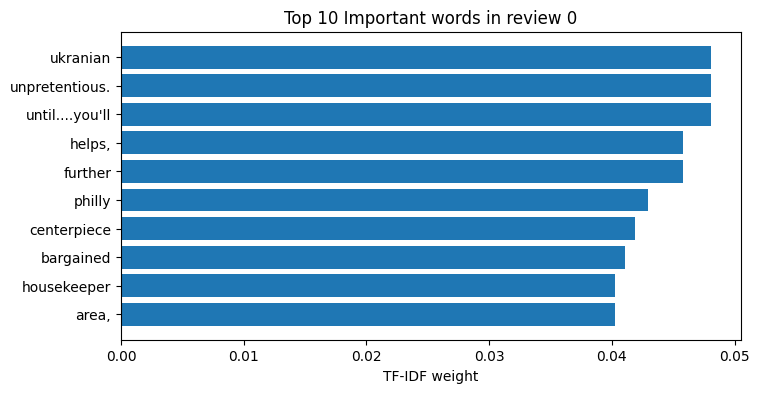

In [175]:
idx_to_word = {v:k for k,v in vocab.items()}

idx = 0 # change num for different review
print(X_train[idx])
row = X_train_tfidf[idx]
print("word : wieght")
for i,v in enumerate(row):
        if v > 0:
            print(idx_to_word[i], " : ", v)

row = X_train_tfidf[idx]

# top 10 words
top = 10
top_idx = np.argsort(row)[-1*top:]
top_words = [idx_to_word[i] for i in top_idx]
top_vals = row[top_idx]

plt.figure(figsize=(8,4))
plt.barh(top_words, top_vals)
plt.xlabel("TF-IDF weight")
plt.title(f"Top 10 Important words in review {idx}")
plt.show()

## SVD

In [176]:
start = time.time()

k = 30 # k = 100 is too big for 50K IMDB data base it does not over 

U, S, Vt = svds(X_train_tfidf, k=k)

X_reduced = U[:, :k].dot(np.diag(S[:k]))

svd_time = time.time() - start

print("Reduced shape:", X_reduced.shape)

Reduced shape: (10000, 30)


## CLustering

In [177]:
def init_centroids(
    X: np.ndarray,
    K: int,
    seed: int,
) -> np.ndarray:
    np.random.seed(seed=seed)

    N, d = X.shape
    c = None
    
    c = np.zeros((K,d))
    idx = np.random.randint(N)
    c[0] = X[idx]

    for k in range(1, K):
        dist_sq = np.min(np.sum((X[:, None] - c[:k]) ** 2, axis=2), axis=1)
        total = np.sum(dist_sq)

        if total == 0:
            idx = np.random.randint(N)
        else:
            prob = dist_sq / total
            idx = np.random.choice(N, p=prob)
        c[k] = X[idx]
    return c

In [178]:

def assign_clusters(X: np.ndarray, C: np.ndarray) -> np.ndarray:
    z = None
    dist_sq = np.sum((X[:, None] - C) ** 2, axis=2)
    z = np.argmin(dist_sq, axis=1)

    return z

In [179]:

def update_centroids(
    X: np.ndarray,
    z: np.ndarray,
    K: int,
    seed: int = 0,
) -> np.ndarray:
    np.random.seed(seed=seed)
    N, d = X.shape
    c_new = np.zeros((K,d))

    for k in range(K):
        points = X[z == k]

        if len(points) == 0:
            idx = np.random.randint(0, N)
            c_new[k] = X[idx]
        else:
            c_new[k] = np.mean(points, axis=0)
    return c_new

In [180]:
def kmeans(
    X: np.ndarray,
    K: int,
    seed: int,
    max_iters: int = 100,
    tol: float = 1e-6,
) -> dict:
    c = init_centroids(X, K, seed)

    history = []
    z = None
    J = None

    for i in range(max_iters):
        z = assign_clusters(X,c)

        dist_sq = np.sum((X - c[z])**2, axis=1)
        J = np.sum(dist_sq)
        history.append(J)

        c_new = update_centroids(X, z, K, seed)

        shift = np.linalg.norm(c_new - c)
        c = c_new

        if shift < tol:
            break
    
    z = assign_clusters(X, c)
    dist_sq = np.sum((X - c[z])**2, axis=1)
    J = np.sum(dist_sq)

    return{
        "centroids": c,
        "labels": z,
        "inertia": J,
        "history": history,
    }

In [181]:
start = time.time()

result = kmeans(X_reduced, K=2, seed=42)

end_train = time.time() - start

labels = result["labels"]
centroids = result["centroids"]
history = result["history"]

print("Final inertia:", result["inertia"])
print("Cluster counts:")
for k in range(5):
    print(k, np.sum(labels == k))



Final inertia: 33.01129516238828
Cluster counts:
0 5619
1 4381
2 0
3 0
4 0


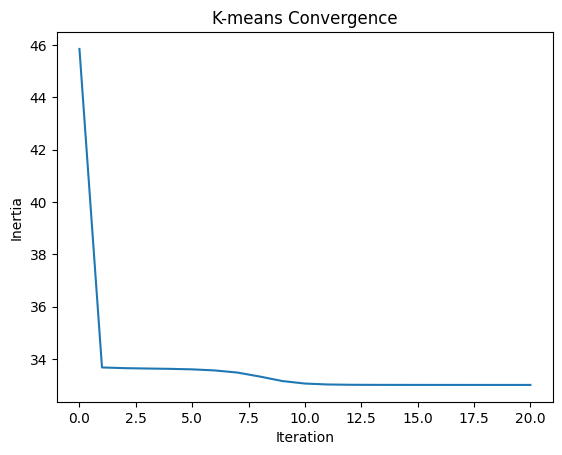

In [182]:
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("K-means Convergence")
plt.show()

In [183]:
def cluster_to_label_map(cluster_labels, y_true, K):

    mapping = {}

    for k in range(K):
        idx = np.where(cluster_labels == k)[0]

        if len(idx) == 0:
            mapping[k] = 0
        else:
            majority = np.round(np.mean(y_true[idx]))
            mapping[k] = int(majority)

    return mapping

In [184]:
def predict_cluster(X, centroids):

    dist_sq = np.sum((X[:, None] - centroids)**2, axis=2)

    labels = np.argmin(dist_sq, axis=1)

    return labels

In [185]:
def cluster_predictions(cluster_labels, mapping):

    y_pred = np.array([mapping[z] for z in cluster_labels])

    return y_pred

In [186]:
def evaluate_clustering_model(X_test, y_test, centroids, mapping):

    cluster_labels = predict_cluster(X_test, centroids)

    y_pred = cluster_predictions(cluster_labels, mapping)

    metrics = evaluate_predictions(y_test, y_pred, model_name="KMeans")

    return metrics

In [187]:
centroids = result["centroids"]
train_clusters = result["labels"]
mapping = cluster_to_label_map(train_clusters, y_train, K=2)

In [ ]:
X_test_reduced = X_test_tfidf.dot(Vt.T)

start = time.time()
pred_eval = evaluate_clustering_model(
    X_test_reduced,
    y_test,
    centroids,
    mapping
)

ent_test = time.time() - start

{'model': 'KMeans', 'accuracy': np.float64(0.5973), 'precision': np.float64(0.5856061939116664), 'recall': np.float64(0.6656), 'f1': np.float64(0.623045960872414)}


In [189]:
print(f"\n===== {pred_eval["model"]} =====")
print(f"Weighting time: {TF_idf_time}")
print(f"Train Time: {end_train}")
print(f"Test Time: {ent_test}")
print(f"Accuracy : {pred_eval["accuracy"]:.4f}")
print(f"Precision: {pred_eval["precision"]:.4f}")
print(f"Recall   : {pred_eval["recall"]:.4f}")
print(f"F1-score : {pred_eval["f1"]:.4f}")



===== KMeans =====
Weighting time: 8.943546772003174
Train Time: 0.0345461368560791
Test Time: 0.0021009445190429688
Accuracy : 0.5973
Precision: 0.5856
Recall   : 0.6656
F1-score : 0.6230


## Demo

In [190]:
def sentence_to_tfidf(sentence, vocab, idf):
    words = tokenize(sentence)
    vec = np.zeros(len(vocab), dtype=np.float32)

    # term frequency for single sentence
    for w in words:
        if w in vocab:
            j = vocab[w]
            vec[j] += 1

    if len(words) > 0:
        vec = vec / len(words)

    vec = vec * idf
    return vec


def predict_sentence_clustering(sentence):
    # sentence -> tfidf
    vec = sentence_to_tfidf(sentence, vocab, idf)

    # tfidf -> reduced space using train SVD basis
    x_reduced = vec.dot(Vt.T)   # shape: (k,)

    # nearest centroid
    dist_sq = np.sum((centroids - x_reduced) ** 2, axis=1)
    cluster = np.argmin(dist_sq)

    # cluster -> sentiment label
    pred = mapping[cluster]

    label = "Positive" if pred == 1 else "Negative"
    return label, cluster


while True:
    text = input("Enter a review (type 'quit' to stop): ")

    if text.lower() == "quit":
        break

    label, cluster = predict_sentence_clustering(text)
    print(f"Input: {text}")
    print(f"Prediction: {label}")
    print(f"Cluster: {cluster}\n")

Input: i love this movie
Prediction: Negative
Cluster: 1

Input: i hate this movie
Prediction: Negative
Cluster: 1

Input: movie is perfect
Prediction: Negative
Cluster: 1

Input: quir
Prediction: Positive
Cluster: 0

